# Importing Data

Provided are 1610 audio recordings of sustained vowels, either "eeeee" or "oooo".



In [2]:
# check if ../data/ exists, if not: clone git repo and change path repo to that
import os
import csv
import numpy as np

import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(1)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

import os

os.environ["KERAS_BACKEND"] = "jax"

if not os.path.isdir("../data"):
    print("data directory not found, cloning repository…")
    !rm -rf ./vowel-detection/
    !git clone https://github.com/danielstebbings/vowel-detection
    data_path = "./vowel-detection/data/"
else:
    print("Found data")
    data_path = "../data/"

# Read label csv
with open(data_path+"/train/"+"train_labels.csv", newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    train_labels = []
    for row in reader:
        train_labels.append(int(row['Labels']))

# Import data into keras dataset
train = keras.utils.audio_dataset_from_directory(
    data_path+"train/",
    labels=train_labels,
    label_mode="binary",
    batch_size=None,
    sampling_rate=None,
    output_sequence_length=None,
    ragged=False,
    shuffle=True,
    seed=1, #  Set seed for repeatability.
    validation_split=0.1,
    subset="training",
    follow_links=False,
    verbose=True,
)

val = keras.utils.audio_dataset_from_directory(
    data_path+"train/",
    labels=train_labels,
    label_mode="binary",
    batch_size=None,
    sampling_rate=None,
    output_sequence_length=None,
    ragged=False,
    shuffle=True,
    seed=1, #  Set seed for repeatability.
    validation_split=0.1,
    subset="validation",
    follow_links=False,
    verbose=True,
)

SAMPLE_RATE = 50000
NUM_CLASSES = 2

2026-03-20 17:42:42.885728: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-20 17:42:42.886598: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-20 17:42:42.890444: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-20 17:42:42.897198: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774028562.907810   94786 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774028562.91

Found data
Found 1450 files belonging to 2 classes.
Using 1305 files for training.
Found 1450 files belonging to 2 classes.
Using 145 files for validation.


2026-03-20 17:42:44.620191: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# Check out a single sample from the dataset

mostmax, mostmin = 0.0, +np.inf
maxlen,  minlen  = 0,   +np.inf

for sample in train:
    # Sound is a tuple of (data[], label)
    # data[] has a variable size in the 10s of k
    # label is a tensor of 1 value, either 1 or 0.
    #print(sound)
    #print("Data size: "+ str(np.size(sound[0])))
    #print("Label: "+ str(int(sound[1][0])))
    # Find the max max value in dataset
    audio,label = sample

    curmax = np.max(audio)
    curmin = np.min(audio)

    curlen = len(audio)

    if curmax > mostmax:
        mostmax = curmax
    if curmin < mostmin:
        mostmin = curmin

    if curlen > maxlen:
        maxlen = curlen
    elif curlen < minlen:
        minlen = curlen
    
# We're normalised between +-1, so that's nice!
print("most max "+ str(mostmax))
print("most min "+ str(mostmin))

# The length of audio clips varies massively.
print("Longest "+ str(maxlen))
print("Shortest " + str(minlen))


most max 0.98654175
most min -0.9449768
Longest 226236
Shortest 13320


2026-03-20 17:42:44.878213: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


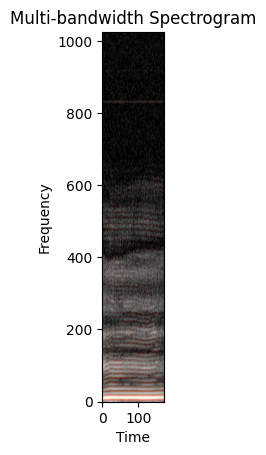

In [4]:
import matplotlib.pyplot as plt

# Testing out spectrograms.
# So many magic numbers in these Keras examples ...

# From https://keras.io/examples/audio/stft/#define-functions-to-read-and-preprocess-the-wav-files
def plot_multi_bandwidth_spectrogram(sample_wav_data):
    # All spectrograms must use the same `fft_length`, `frame_step`, and
    # `padding="same"` in order to produce spectrograms with identical shapes,
    # hence aligning them together. `expand_dims` ensures that the shapes are
    # compatible with image models.

    spectrograms = np.concatenate(
        [
            keras.layers.STFTSpectrogram(
                mode="log",
                frame_length=SAMPLE_RATE * x // 1000,
                frame_step=SAMPLE_RATE * 4 // 1000,
                fft_length=2048,
                padding="same",
                expand_dims=True,
            )(sample_wav_data[None, ...])[0, ...]
            for x in [8,16,20]
        ],
        axis=-1,
    ).transpose([1, 0, 2])

    # normalize each color channel for better viewing
    mn = spectrograms.min(axis=(0, 1), keepdims=True)
    mx = spectrograms.max(axis=(0, 1), keepdims=True)
    spectrograms = (spectrograms - mn) / (mx - mn)

    plt.imshow(spectrograms, origin="lower")
    plt.title("Multi-bandwidth Spectrogram")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

for sample in train:
    audio, label = sample
    plot_multi_bandwidth_spectrogram(audio)
    break



## Preprocessing
Let's instead convert the input to a 1D fft and train a dense

In [11]:
BLOCK_LENGTH  = 25000

# Preprocess dataset into blocks
# See: https://stackoverflow.com/questions/47337031/how-to-expand-tf-data-dataset-with-additional-example-transformations-in-tensorf
def to_blocks(audio, label):

    print(f"label: {label} length: {len(audio)} N blocks: {len(audio)//BLOCK_LENGTH}")

    block = audio[0:BLOCK_LENGTH]
    ds = tf.data.Dataset.from_tensors((block, label))
    for block_it in range(2, 1+len(audio) // BLOCK_LENGTH):
        block = audio[(block_it-1)*BLOCK_LENGTH:(block_it)*BLOCK_LENGTH ]
        block_ds = tf.data.Dataset.from_tensors((block, label))
        if block_it == 0:
            ds = block_ds
        else:
            ds = ds.concatenate(block_ds)
    return ds

def dstoblocks(ds):
    first = True
    for sample in ds:
        audio, label = sample
        print(len(audio))
        print(len(label))
        block = to_blocks(audio,label)
        if first:
            blocked = block
            first = False
        else:
            blocked = blocked.concatenate(block)
        
    return blocked

train_blocks = dstoblocks(train)
val_blocks = dstoblocks(val)

            

67016
1
label: [1.] length: 67016 N blocks: 2
32693
1
label: [1.] length: 32693 N blocks: 1
67751
1
label: [1.] length: 67751 N blocks: 2
38846
1
label: [1.] length: 38846 N blocks: 1
35327
1
label: [0.] length: 35327 N blocks: 1
73670
1
label: [1.] length: 73670 N blocks: 2
129418
1
label: [1.] length: 129418 N blocks: 5
71747
1
label: [1.] length: 71747 N blocks: 2
80001
1
label: [0.] length: 80001 N blocks: 3
57036
1
label: [1.] length: 57036 N blocks: 2
65719
1
label: [1.] length: 65719 N blocks: 2
66381
1
label: [1.] length: 66381 N blocks: 2
98470
1
label: [1.] length: 98470 N blocks: 3
85077
1
label: [0.] length: 85077 N blocks: 3
60838
1
label: [1.] length: 60838 N blocks: 2
83091
1
label: [1.] length: 83091 N blocks: 3
38974
1
label: [1.] length: 38974 N blocks: 1
88879
1
label: [1.] length: 88879 N blocks: 3
121199
1
label: [0.] length: 121199 N blocks: 4
70160
1
label: [1.] length: 70160 N blocks: 2
59875
1
label: [0.] length: 59875 N blocks: 2
92149
1
label: [0.] length: 92

In [12]:
for sample in val_blocks:
    audio, label = sample

    print(label[0])
    print(len(label))
    print(len(audio))
    
print(len(train_blocks))

tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(0.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(0.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(0.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(1.0, shape=(), dtype=float32)
1
25000
tf.Tensor(0.0, shape=(), dtype=float32)


# Models


## STFT Based
Working from this example: https://keras.io/examples/audio/stft/

In [31]:
input = keras.layers.Input((BLOCK_LENGTH, 1))
spectrograms = [
    keras.layers.STFTSpectrogram(
        mode="log",
        frame_length=BLOCK_LENGTH * frame_size // 1000,
        frame_step=BLOCK_LENGTH * 2 // 1000,
        fft_length=999,
        padding="same",
        expand_dims=True,
        # trainable=True,  # trainable by default
    )(input)
    for frame_size in [15, 20, 25]  # frame size in milliseconds
]

multi_spectrograms =  keras.layers.Concatenate(axis=-1)(spectrograms)

img_model = keras.applications.MobileNet(
    input_shape=(500,500,3),
    alpha=1.0,
    depth_multiplier=1,
    dropout=0.001,
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    pooling="max",
)
output = img_model(multi_spectrograms)

output =  keras.layers.Dropout(0.5)(output)
output =  keras.layers.Dense(256, activation="relu")(output)
output =  keras.layers.Dense(256, activation="relu")(output)
output =  keras.layers.Dense(NUM_CLASSES, activation="softmax")(output)
model2d = keras.Model(input, output, name="model_2d_trainble_stft")

model2d.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model2d.summary()



/tmp/ipykernel_94786/4277754240.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  img_model = keras.applications.MobileNet(


Model: "model_2d_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31      │ (None, 25000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_48 │ (None, 500, 500,  │    375,000 │ input_layer_31[0… │
│ (STFTSpectrogram)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_49 │ (None, 500, 500,  │    500,000 │ input_layer_31[0… │
│ (STFTSpectrogram)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_50 │ (None, 500, 500,  │    625,000 │ input_layer_31[0… │
│ (STFTSpectrogram)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_15      │ (None, 500, 500,  │          0 │ stft_spectrogram… │
│ (Concatenate)       │ 3)                │            │ stft_spectrogram… │
│                     │                   │            │ stft_spectrogram… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_1.00_224  │ (None, 1024)      │  3,228,864 │ concatenate_15[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 1024)      │          0 │ mobilenet_1.00_2… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 256)       │    262,400 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 256)       │     65,792 │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 2)         │        514 │ dense_46[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,057,570 (19.29 MB)

 Trainable params: 5,035,682 (19.21 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [32]:
history_model1d = model2d.fit(
    train_blocks,
    batch_size=1,
    epochs=1,
    validation_data=val_blocks,
)

ValueError: Exception encountered when calling Functional.call().

[1mInput 0 with name 'input_layer_32' of layer 'mobilenet_1.00_224' is incompatible with the layer: expected shape=(None, 500, 500, 3), found shape=(None, 1, 500, 3)[0m

Arguments received by Functional.call():
  • inputs=tf.Tensor(shape=(None, 1), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>